# 1. Data preprocessing

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Set the style
plt.style.use('ggplot')

# Load the edge data
edges_data = pd.read_csv('data/large_twitch_edges.csv')

# Load the feature data
features_data = pd.read_csv('data/large_twitch_features.csv')

In [24]:


# Create an directed graph
#G = nx.from_pandas_edgelist(edges_data, 'numeric_id_1', 'numeric_id_2', create_using=nx.DiGraph())

G_original = nx.from_pandas_edgelist(edges_data, 'numeric_id_1', 'numeric_id_2', create_using=nx.Graph())


# Ensure required columns are in the dataframe
required_columns = ['numeric_id', 'views', 'life_time', 'created_at', 'updated_at', 'language']
if all(col in features_data.columns for col in required_columns):
    # Prepare the node attributes as a dictionary of dictionaries
    attributes = features_data.set_index('numeric_id')[required_columns[1:]].to_dict(orient='index')
    nx.set_node_attributes(G_original, attributes)
else:
    print("Required columns are not in the features_data")

## Random sample

In [3]:

num_nodes = G_original.number_of_nodes()
num_edges = G_original.number_of_edges()
density = nx.density(G_original)

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Density: {density:.4f}")

Number of nodes: 168114
Number of edges: 6797557
Density: 0.0005


In [48]:
import random

# Random sampling of nodes
sample_size = 2500
sampled_nodes = random.sample(G_original.nodes(), sample_size)
G_sampled_random = G_original.subgraph(sampled_nodes)

# Check the size of the final graph
print(f"Final graph has {G_sampled_random.number_of_nodes()} nodes and {G_sampled_random.number_of_edges()} edges")



Final graph has 2500 nodes and 1633 edges


/tmp/ipykernel_268734/546929196.py:5: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_nodes = random.sample(G_original.nodes(), sample_size)


## Largest number of component

In [49]:
# Ensure your graph is connected (for diameter and average shortest path calculation)
if not nx.is_connected(G_sampled_random):
    print("Warning: Graph is not connected. Analyzing properties of the largest connected component.")

# Get the largest connected component for analysis
largest_cc = max(nx.connected_components(G_sampled_random), key=len)
G_LNC = G_sampled_random.subgraph(largest_cc)

# print results



In [50]:

num_nodes = G_LNC.number_of_nodes()
num_edges = G_LNC.number_of_edges()
density = nx.density(G_LNC)

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Density: {density:.4f}")

Number of nodes: 999
Number of edges: 1550
Density: 0.0031


### Visulize

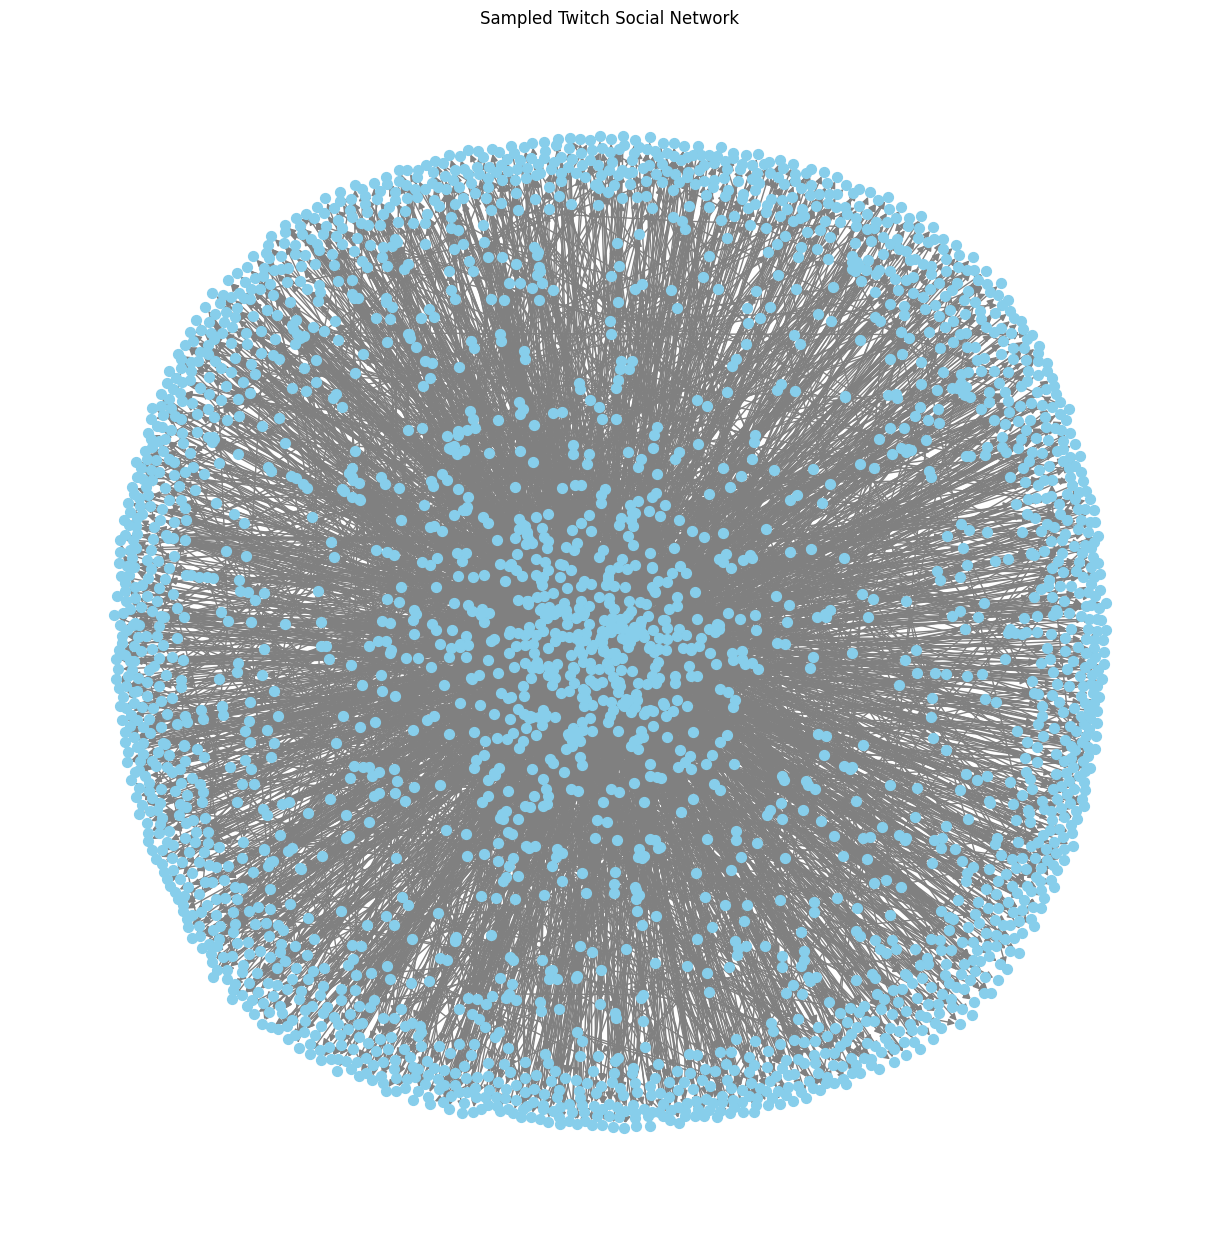

In [11]:
# Visualize the sampled graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_sampled_random)
nx.draw(G_sampled_random, pos, node_color='skyblue', node_size=50, edge_color='gray', with_labels=False)
plt.title('Sampled Twitch Social Network')
plt.show()

# Save the sampled graph for further analysis
nx.write_edgelist(G_sampled_random, 'sampled_graph.edgelist')

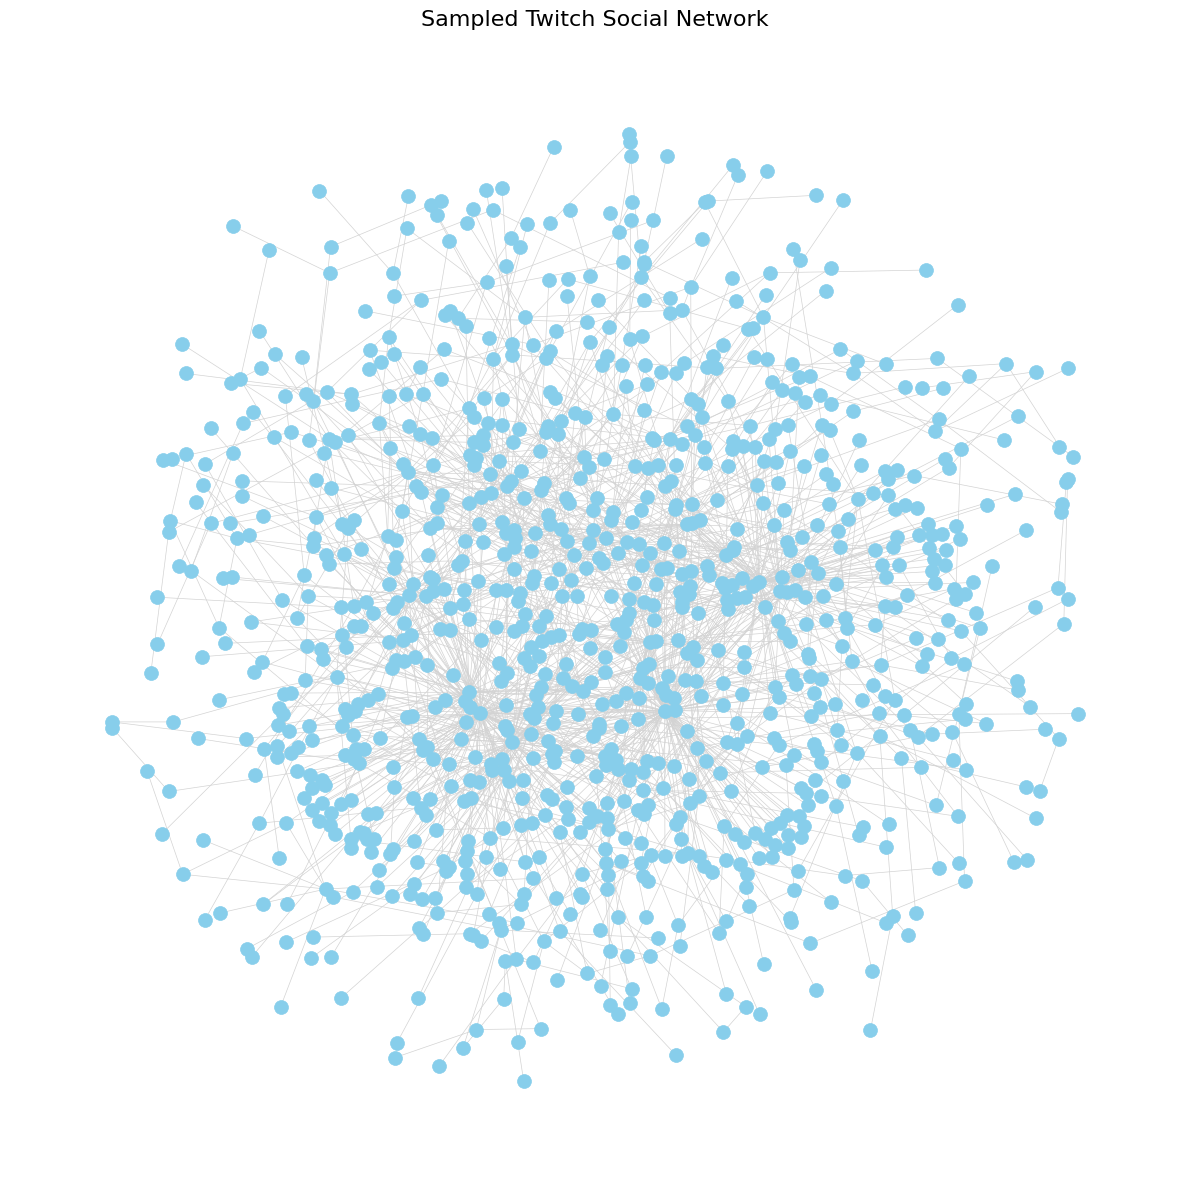

In [95]:
import matplotlib.pyplot as plt
import networkx as nx

# Visualize the sampled graph
plt.figure(figsize=(12, 12))

# Improved layout for better readability
pos = nx.spring_layout(G_LNC, k=0.15, iterations=50)

# Draw nodes and edges with adjusted parameters
nx.draw_networkx_nodes(G_LNC, pos, node_color='skyblue', node_size=100)
nx.draw_networkx_edges(G_LNC, pos, edge_color='lightgray', width=0.5)

# Optionally add labels for better identification
# nx.draw_networkx_labels(G_final, pos, font_size=8, font_color='black')

plt.title('Sampled Twitch Social Network', fontsize=16)
plt.axis('off')  # Turn off axis for cleaner appearance
plt.tight_layout()
plt.show()

# Save the sampled graph for further analysis
nx.write_edgelist(G_LNC, 'sampled_graph.edgelist')


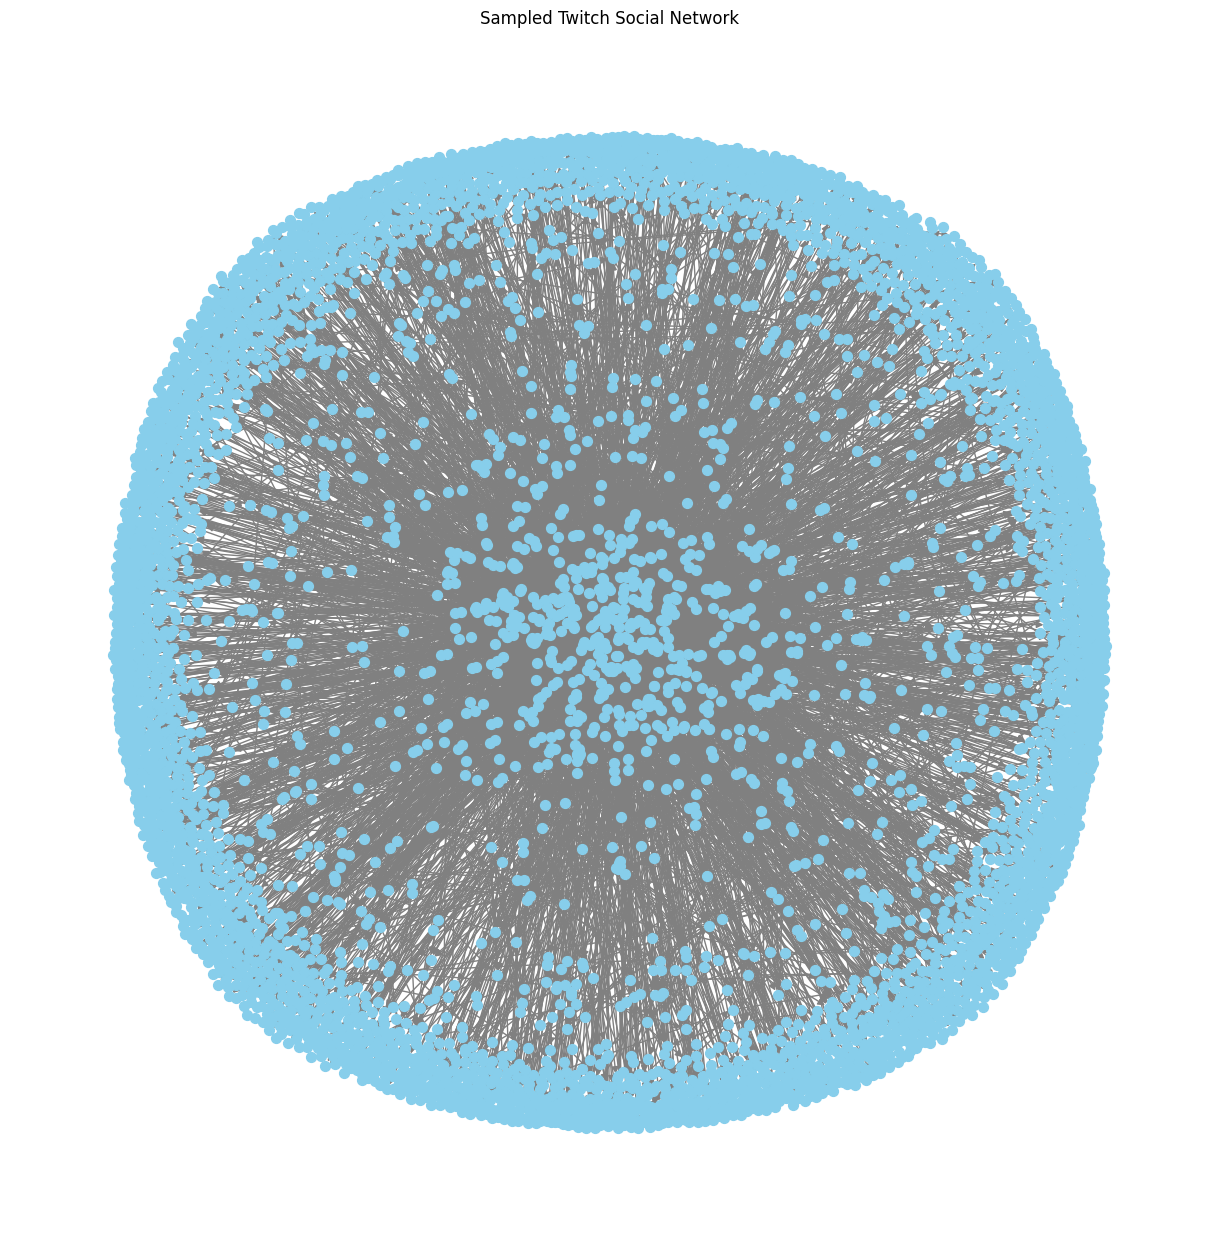

In [10]:
# Visualize the sampled graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_sampled_random)
nx.draw(G_sampled_random, pos, node_color='skyblue', node_size=50, edge_color='gray', with_labels=False)
plt.title('Sampled Twitch Social Network')
plt.show()

# Save the sampled graph for further analysis
nx.write_edgelist(G_sampled_random, 'sampled_graph.edgelist')

# 2. Analysis

## Descriptive analysis

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import powerlaw




Number of nodes: 7142
Number of edges: 22631
Density: 0.0009


In [52]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import powerlaw

num_nodes = G_LNC.number_of_nodes()
num_edges = G_LNC.number_of_edges()
density = nx.density(G_LNC)

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Density: {density:.4f}")


Number of nodes: 999
Number of edges: 1550
Density: 0.0031


In [53]:
# Diameter (only for connected graphs)
try:
    diameter = nx.diameter(G_LNC)
except nx.NetworkXError:
    diameter = "Not applicable (graph is not connected)"
print(f"Diameter: {diameter}")


Diameter: 14


In [51]:
# Average Shortest Path
avg_shortest_path = nx.average_shortest_path_length(G_LNC)


print(f"Avg. Shortest Path: {avg_shortest_path:.4f}")

Avg. Shortest Path: 4.7898


In [54]:
import networkx as nx

cluster_coefficient = nx.average_clustering(G_LNC)

print(f"Cluster Coefficient: {cluster_coefficient:.4f}")

Cluster Coefficient: 0.0529


In [55]:
num_components = nx.number_connected_components(G_LNC)
largest_cc_size = len(max(nx.connected_components(G_LNC), key=len))

print(f"Number of components: {num_components}")
print(f"Size of the giant component: {largest_cc_size}")

Number of components: 1
Size of the giant component: 999


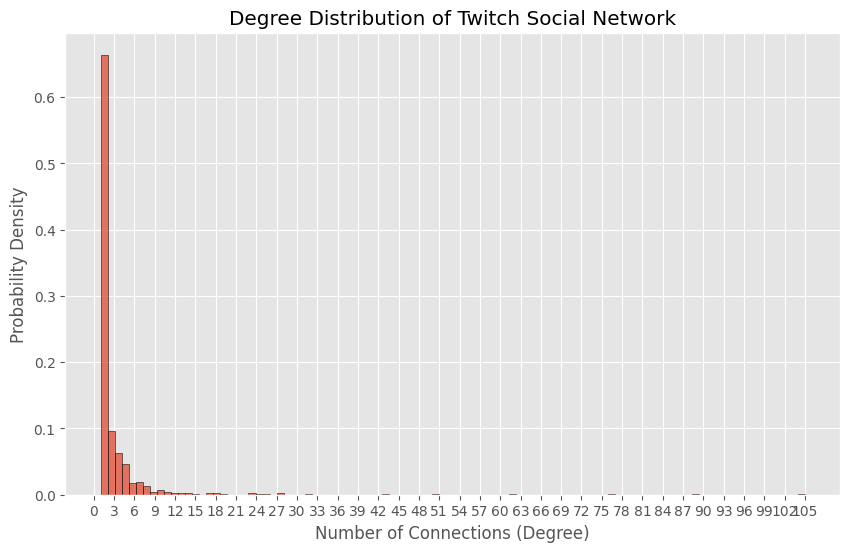

Calculating best minimal value for power law fit
Degree distribution shape: Power law exponent (alpha) = 3.03


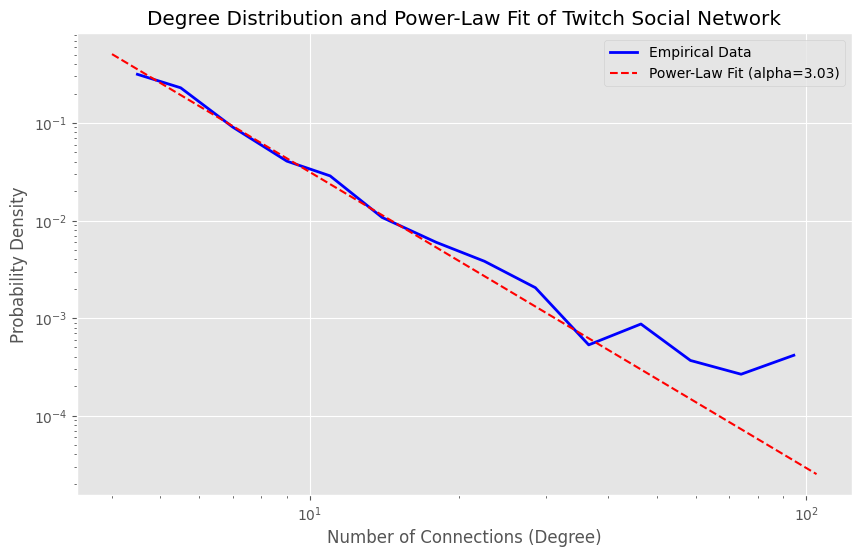

In [71]:
import networkx as nx
import powerlaw
import matplotlib.pyplot as plt

# Assuming G_LNC is your graph

# Degree Distribution
degrees = [G_LNC.degree(node) for node in G_LNC.nodes()]

# Plot degree distribution with descriptive x-values
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=100, density=True, alpha=0.75, edgecolor='black')
plt.xlabel('Number of Connections (Degree)')
plt.ylabel('Probability Density')
plt.title('Degree Distribution of Twitch Social Network')
plt.grid(True)

# Customize x-ticks
max_degree = max(degrees)
step = max_degree // 30 if max_degree > 10 else 1
plt.xticks(range(0, max_degree + 1, step))

plt.show()

# Fit to a power law distribution
fit = powerlaw.Fit(degrees)
alpha = fit.power_law.alpha

print(f"Degree distribution shape: Power law exponent (alpha) = {alpha:.2f}")

# Plot degree distribution and power-law fit for comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the empirical degree distribution
fit.plot_pdf(color='b', linewidth=2, ax=ax, label='Empirical Data')

# Plot the power-law fit
fit.power_law.plot_pdf(color='r', linestyle='--', ax=ax, label=f'Power-Law Fit (alpha={alpha:.2f})')

plt.xlabel('Number of Connections (Degree)')
plt.ylabel('Probability Density')
plt.title('Degree Distribution and Power-Law Fit of Twitch Social Network')
plt.legend()
plt.grid(True)

plt.show()


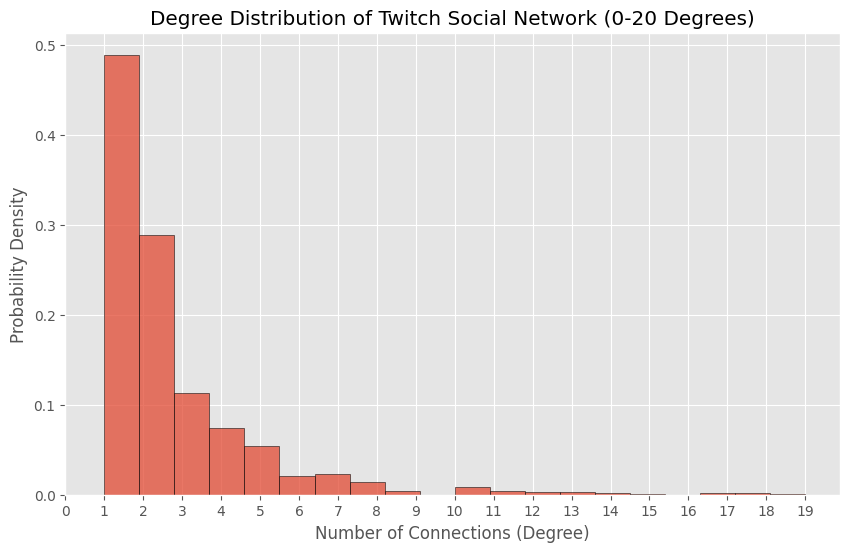

In [76]:
resolution = 20
# Filter degree sequence to include only degrees between 0 and 20
filtered_degrees = [d for d in degrees if 0 <= d <= resolution]

# Plot degree distribution with descriptive x-values (0-20 degrees)
plt.figure(figsize=(10, 6))
plt.hist(filtered_degrees, bins=resolution, density=True, alpha=0.75, edgecolor='black')
plt.xlabel('Number of Connections (Degree)')
plt.ylabel('Probability Density')
plt.title('Degree Distribution of Twitch Social Network (0-20 Degrees)')
plt.grid(True)

# Customize x-ticks
max_degree = max(filtered_degrees)
step = max_degree // 10 if max_degree > 10 else 1
plt.xticks(range(0, max_degree + 1, step))

plt.show()
# 
# # Customize x-ticks
# plt.xticks(range(0, resolution + 1, 1))

plt.show()

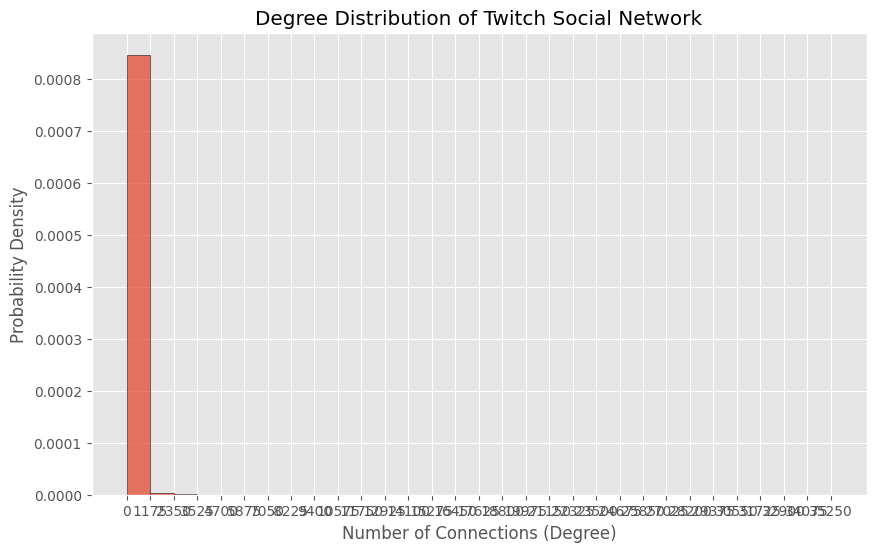

In [68]:
# Assuming G_LNC is your graph

# Degree Distribution
degrees = [G_original.degree(node) for node in G_original.nodes()]

# Plot degree distribution with descriptive x-values
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=30, density=True, alpha=0.75, edgecolor='black')
plt.xlabel('Number of Connections (Degree)')
plt.ylabel('Probability Density')
plt.title('Degree Distribution of Twitch Social Network')
plt.grid(True)

# Customize x-ticks
max_degree = max(degrees)
step = max_degree // 30 if max_degree > 10 else 1
plt.xticks(range(0, max_degree + 1, step))


In [81]:
# Random graph comparison
random_graph = nx.gnm_random_graph(num_nodes, num_edges)
random_graph_clustering = nx.average_clustering(random_graph)
if nx.is_connected(random_graph):
    random_graph_avg_shortest_path = nx.average_shortest_path_length(random_graph)
else:
    # avg shortest path of lcc
    print("The graph is not connected")
    largest_cc_random_graph = max(nx.connected_components(random_graph), key=len)
    random_graph_avg_shortest_path = nx.average_shortest_path_length(random_graph.subgraph(largest_cc_random_graph))

# Small world comparison (Watts-Strogatz model)
p = 0.1  # Rewiring probability
small_world_graph = nx.watts_strogatz_graph(num_nodes, 10, p)
small_world_graph_clustering = nx.average_clustering(small_world_graph)
if nx.is_connected(small_world_graph):
    small_world_graph_avg_shortest_path = nx.average_shortest_path_length(small_world_graph)
else:
    small_world_graph_avg_shortest_path = None

# Barabasi-Albert model comparison
m = 5  # Number of edges to attach from a new node to existing nodes
barabasi_albert_graph = nx.barabasi_albert_graph(num_nodes, m)
barabasi_albert_graph_clustering = nx.average_clustering(barabasi_albert_graph)
if nx.is_connected(barabasi_albert_graph):
    barabasi_albert_graph_avg_shortest_path = nx.average_shortest_path_length(barabasi_albert_graph)
else:
    barabasi_albert_graph_avg_shortest_path = None

print("Comparison with random graph:")
print(f"  Random graph clustering: {random_graph_clustering:.4f}, Avg. shortest path: {random_graph_avg_shortest_path}")
print("Comparison with small world (Watts-Strogatz) model:")
print(f"  Small world clustering: {small_world_graph_clustering:.4f}, Avg. shortest path: {small_world_graph_avg_shortest_path}")
print("Comparison with Barabasi-Albert model:")
print(f"  Barabasi-Albert clustering: {barabasi_albert_graph_clustering:.4f}, Avg. shortest path: {barabasi_albert_graph_avg_shortest_path}")

The graph is not connected
Comparison with random graph:
  Random graph clustering: 0.0045, Avg. shortest path: 6.102540111121507
Comparison with small world (Watts-Strogatz) model:
  Small world clustering: 0.4938, Avg. shortest path: 4.434318085620691
Comparison with Barabasi-Albert model:
  Barabasi-Albert clustering: 0.0405, Avg. shortest path: 2.979685095917561


In [78]:
if isinstance(G_LNC, nx.DiGraph):
    reciprocity = nx.reciprocity(G_LNC)
    print(f"Reciprocity: {reciprocity:.4f}")
else:
    print("Reciprocity is applicable only for directed graphs.")

Reciprocity is applicable only for directed graphs.


In [79]:
transitivity = nx.transitivity(G_LNC)
triad_census = nx.triadic_census(G_LNC)

print(f"Transitivity: {transitivity:.4f}")
print("Triad Census:")
for key, value in triad_census.items():
    print(f"  {key}: {value}")

NetworkXNotImplemented: not implemented for undirected type

## comparison er model

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Parameters
n = num_nodes  # Number of nodes
p = 0.05  # Probability of edge creation

# Generate Erdős–Rényi random graph
G = nx.erdos_renyi_graph(n, p)
# 
# # Plot the graph
# plt.figure(figsize=(10, 10))
# pos = nx.spring_layout(G)  # Position nodes using Fruchterman-Reingold force-directed algorithm
# nx.draw(G, pos, node_size=50, node_color='skyblue', edge_color='gray', with_labels=False)
# plt.title(f'Erdős–Rényi Random Graph (n={n}, p={p})')
# plt.show()

# Calculate clustering coefficient
clustering_coefficient = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {clustering_coefficient}")

# Calculate average shortest path length
if nx.is_connected(G):
    avg_shortest_path = nx.average_shortest_path_length(G)
    print(f"Average Shortest Path Length: {avg_shortest_path}")
else:
    print("The graph is not connected")

# Calculate the size of the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc)
print(f"Size of the Largest Connected Component: {len(G_lcc)}")

## Centrality measures

In [86]:
import concurrent.futures
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Define a function for each centrality measure
def compute_degree_centrality(G_l):
    return nx.degree_centrality(G_l)

def compute_betweenness_centrality(G_l):
    return nx.betweenness_centrality(G_l)

def compute_closeness_centrality(G_l):
    return nx.closeness_centrality(G_l)

def compute_pagerank(G_l):
    return nx.pagerank(G_l)

# Create a ThreadPoolExecutor
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submit the tasks
    future_dc = executor.submit(compute_degree_centrality, G_LNC)
    future_bc = executor.submit(compute_betweenness_centrality, G_LNC)
    future_cc = executor.submit(compute_closeness_centrality, G_LNC)
    future_pr = executor.submit(compute_pagerank, G_LNC)

    # Retrieve the results
    degree_centrality = future_dc.result()
    betweenness_centrality = future_bc.result()
    closeness_centrality = future_cc.result()
    pagerank = future_pr.result()


In [93]:
# print number of nodes of degree centrality
print(f"Degree Centrality: {len(degree_centrality)} nodes")
# print first 5 values of degree centrality
print("First 5 values of Degree Centrality:")
for node, value in list(degree_centrality.items())[:5]:
    print(f"  Node: {node}, Degree Centrality: {value:.4f}")

Degree Centrality: 999 nodes
First 5 values of Degree Centrality:
  Node: 2055, Degree Centrality: 0.0050
  Node: 83980, Degree Centrality: 0.0020
  Node: 20494, Degree Centrality: 0.0060
  Node: 149518, Degree Centrality: 0.0020
  Node: 14354, Degree Centrality: 0.0060


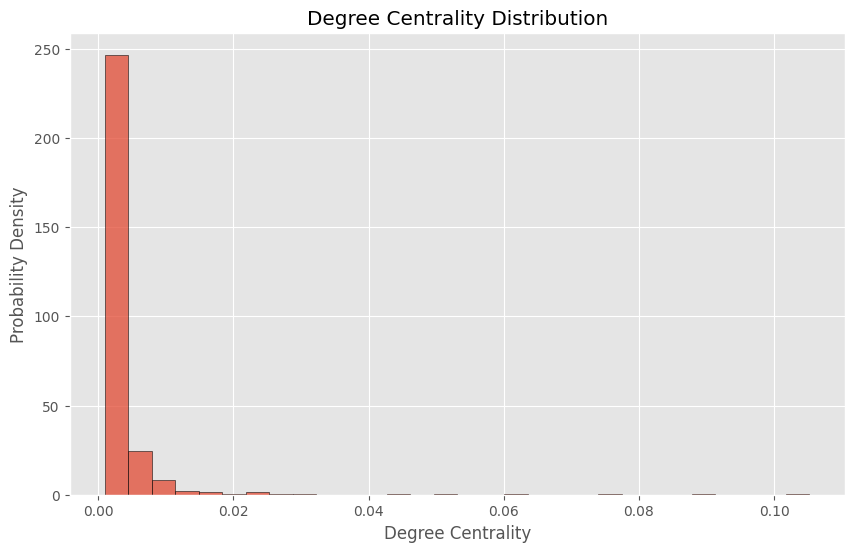

In [92]:
# Plot degree centrality distribution
plt.figure(figsize=(10, 6))
plt.hist(list(degree_centrality.values()), bins=30, density=True, alpha=0.75, edgecolor='black')
plt.xlabel('Degree Centrality')
plt.ylabel('Probability Density')
plt.title('Degree Centrality Distribution')
plt.grid(True)
plt.show()

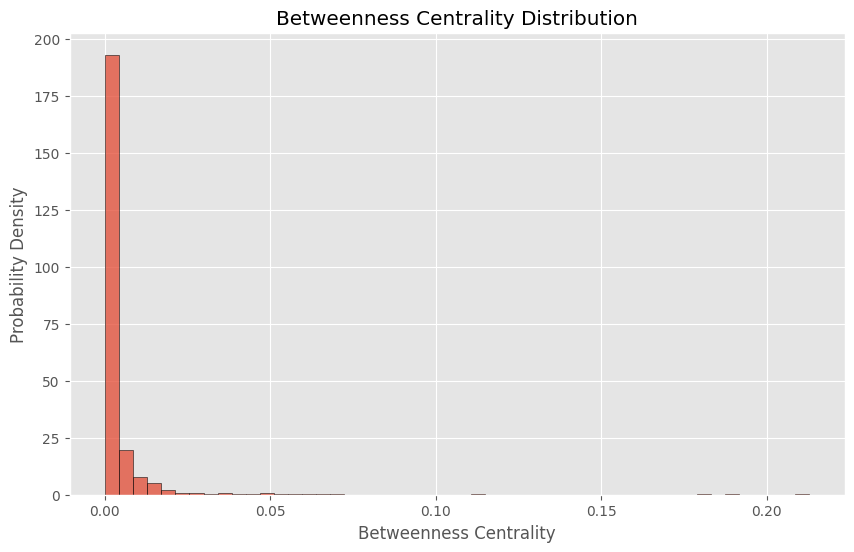

In [90]:
# plot betweenness centrality
plt.figure(figsize=(10, 6))
plt.hist(list(betweenness_centrality.values()), bins=50, density=True, alpha=0.75, edgecolor='black')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Probability Density')
plt.title('Betweenness Centrality Distribution')
plt.grid(True)
plt.show()


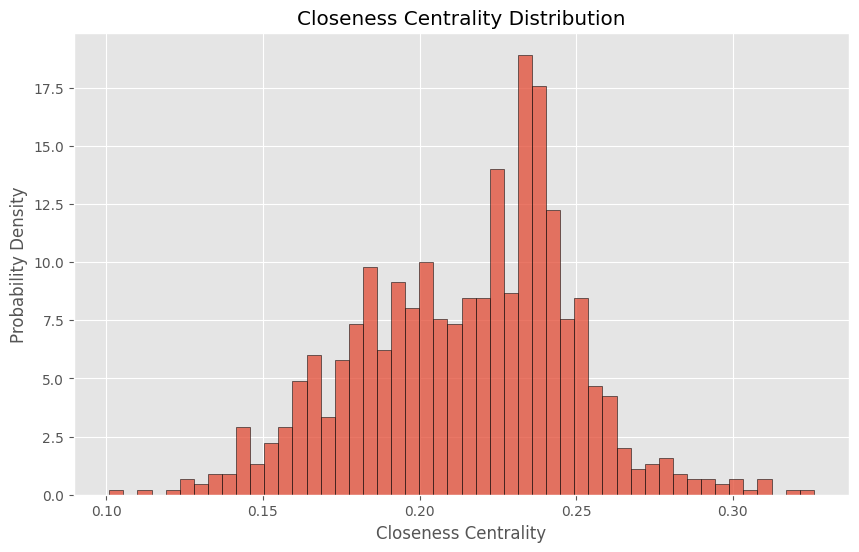

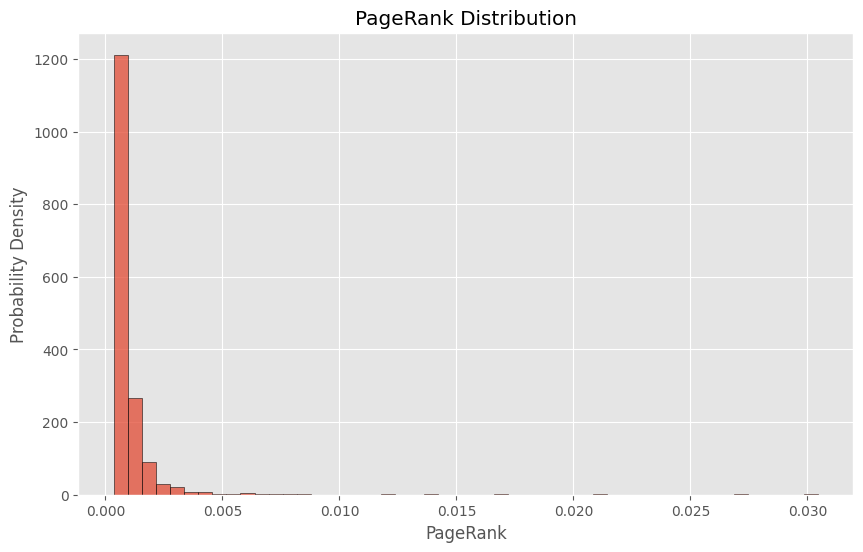

In [91]:
# Helper function to plot centrality distribution
def plot_centrality_distribution(centrality, centrality_name):
    plt.figure(figsize=(10, 6))
    plt.hist(list(centrality.values()), bins=50, density=True, alpha=0.75, edgecolor='black')
    plt.xlabel(centrality_name)
    plt.ylabel('Probability Density')
    plt.title(f'{centrality_name} Distribution')
    plt.grid(True)
    plt.show()


# Plot Closeness Centrality
plot_centrality_distribution(closeness_centrality, 'Closeness Centrality')

# Plot PageRank
plot_centrality_distribution(pagerank, 'PageRank')

 ## Comunity analysis

In [96]:
from matplotlib import cm
import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx

# compute the best partition using Louvain method
partition = community_louvain.best_partition(G_LNC)

# add community attribute to each node
nx.set_node_attributes(G_LNC, partition, 'community')

# 
# # print nodes and their community
# for node, community in partition.items():
#     print(f'Node: {node}, Community: {community}')

In [99]:
# print info about the comunities
num_communities = len(set(partition.values()))
print(f"Number of communities: {num_communities}")

    


Number of communities: 20


Community sizes:


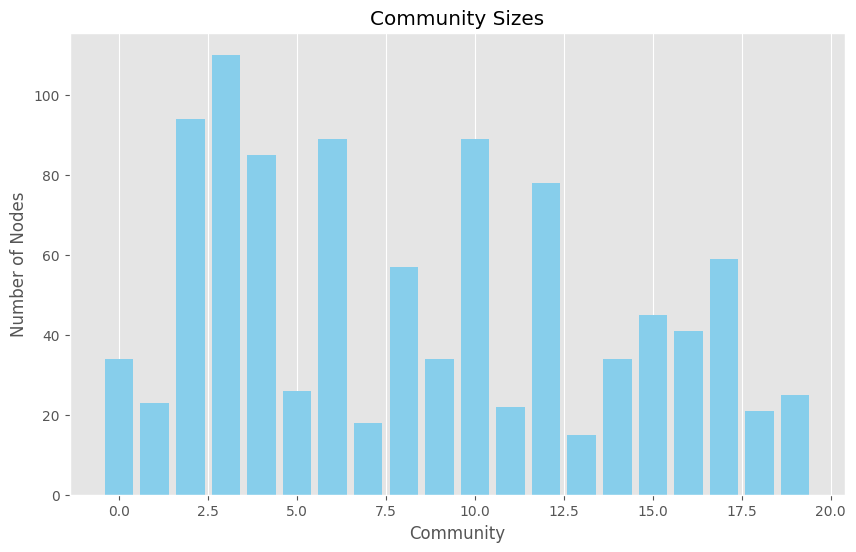

In [104]:

# Count the number of nodes in each community
from collections import Counter
community_sizes = Counter(partition.values())
# order by ommunity_sizes.values())
community_sizes = dict(sorted(community_sizes.items(), key=lambda x: x[1], reverse=True))

print("Community sizes:")
# plot comunity size
plt.figure(figsize=(10, 6))
plt.bar(community_sizes.keys(), community_sizes.values(), color='skyblue')
plt.xlabel('Community')
plt.ylabel('Number of Nodes')
plt.title('Community Sizes')
plt.grid(axis='y')

plt.show()

/tmp/ipykernel_268734/3478237513.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


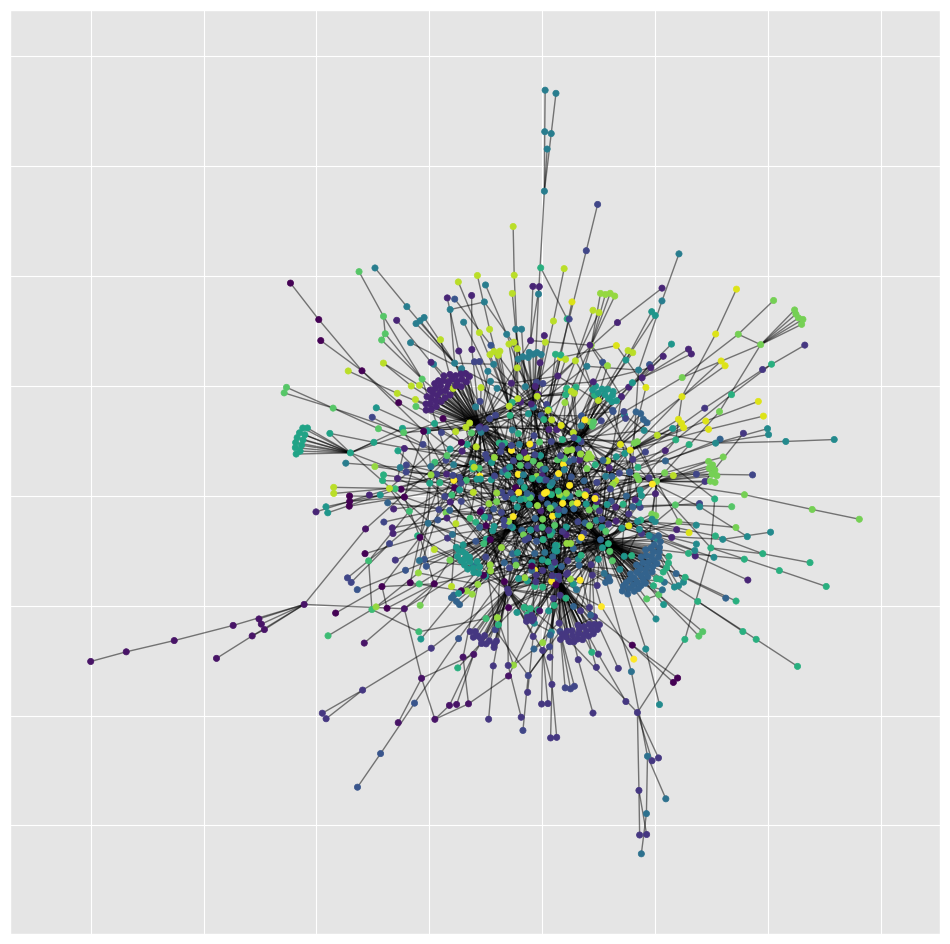

In [98]:
# draw the graph
plt.figure(figsize=(12, 12))  # Adjust the figure size as needed
pos = nx.spring_layout(G_LNC)
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
nx.draw_networkx_nodes(G_LNC, pos, partition.keys(), node_size=20, cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G_LNC, pos, alpha=0.5)

# draw legend title
plt.title('Twitch Social Network with Communities')


plt.show()